# ModernBERT + LoRA — Dual-Gate: Difficulty & Response Time

In [1]:
!pip install -q torchmetrics
!pip install -q --upgrade torchao

import sys
import importlib
if 'imp' not in sys.modules:
    from types import ModuleType
    imp_mock = ModuleType('imp')
    imp_mock.reload = importlib.reload
    sys.modules['imp'] = imp_mock

%reload_ext autoreload
%autoreload 2
%matplotlib inline

import datetime, os, random, shutil, time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import pearsonr, kendalltau

import torch
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler, TensorDataset
from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup,
)
from peft import LoraConfig, TaskType, get_peft_model
from torchmetrics.regression import KendallRankCorrCoef

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 57.1 MB/s eta 0:00:00


In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU: {torch.cuda.get_device_name(0)}  ({torch.cuda.device_count()} device(s))")
else:
    device = torch.device("cpu")
    print("No GPU available — using CPU.")

use_amp = device.type == "cuda"

GPU: Tesla T4  (1 device(s))


In [3]:
# Updated for explicit pathing in Google Colab
data_path = "/content/Our/train_final_extended.csv"

dataset = pd.read_csv(data_path)
print(f"Loaded {len(dataset):,} training records.")
print(f"Columns: {list(dataset.columns)}")

Loaded 466 training records.
Columns: ['ItemNum', 'ItemStem_Text', 'Answer__A', 'Answer__B', 'Answer__C', 'Answer__D', 'Answer__E', 'Answer__F', 'Answer__G', 'Answer__H', 'Answer__I', 'Answer__J', 'Answer_Key', 'Answer_Text', 'ItemType', 'EXAM', 'Difficulty', 'Response_Time', 'gemma_thinking', 'gemma_answer', 'gemma_confidence', 'llama_thinking', 'llama_answer', 'llama_confidence', 'answers_input', 'q_answers_input', 'all_input', 'q_a_input', 'llms_a_input', 'q_llms_a_input']


In [4]:
dataset

,ItemNum,ItemStem_Text,Answer__A,Answer__B,Answer__C,Answer__D,Answer__E,Answer__F,Answer__G,Answer__H,...,gemma_confidence,llama_thinking,llama_answer,llama_confidence,answers_input,q_answers_input,all_input,q_a_input,llms_a_input,q_llms_a_input
0,91,"Over 1 year, a study is conducted to assess th...",Case-control study,Crossover study,Open-labeled clinical trial,Randomized clinical trial,"Single-blind, randomized, controlled trial",NaN,NaN,NaN,...,4.0,The study involves patients with chronic myelo...,C,4,Case-control study. Crossover study. Open-labe...,"Over 1 year, a study is conducted to assess th...","Over 1 year, a study is conducted to assess th...","Over 1 year, a study is conducted to assess th...",The study describes a scenario where patients ...,"Over 1 year, a study is conducted to assess th..."
1,288,A previously healthy 52-year-old woman comes t...,Calcitriol production by activated macrophages,Local resorption of bone by metastases,Parathyroid hormone-related peptide secretion,Secretion of parathyroid hormone,Secretion of thyroid-stimulating hormone,NaN,NaN,NaN,...,5.0,Given the patient's symptoms and laboratory fi...,A,4,Calcitriol production by activated macrophages...,A previously healthy 52-year-old woman comes t...,A previously healthy 52-year-old woman comes t...,A previously healthy 52-year-old woman comes t...,The patient presents with hypercalcemia (11.1 ...,A previously healthy 52-year-old woman comes t...
2,160,A 42-year-old woman is brought to the emergenc...,CT scan of the abdomen,CT scan of the chest,Thoracoscopy,Laparotomy,Thoracotomy,NaN,NaN,NaN,...,4.0,Given the patient's presentation with shortnes...,D,4,CT scan of the abdomen. CT scan of the chest. ...,A 42-year-old woman is brought to the emergenc...,A 42-year-old woman is brought to the emergenc...,A 42-year-old woman is brought to the emergenc...,The patient is hemodynamically unstable (BP 80...,A 42-year-old woman is brought to the emergenc...
3,514,A 37-year-old woman comes to the office for a ...,Corticosteroid therapy,Taking frequent breaks from the paper-bleachin...,Undergoing monthly pulmonary function testing,Using a respirator at work,Washing daily after work with a chlorhexidine-...,NaN,NaN,NaN,...,5.0,Given the patient's concern about exposure to ...,D,5,Corticosteroid therapy. Taking frequent breaks...,A 37-year-old woman comes to the office for a ...,A 37-year-old woman comes to the office for a ...,A 37-year-old woman comes to the office for a ...,The patient is asking about occupational expos...,A 37-year-old woman comes to the office for a ...
4,452,A 71-year-old woman comes to the physician bec...,Cellular,Complement,Humoral,Phagocytic cell,Toll-like receptor,NaN,NaN,NaN,...,5.0,The patient's presentation of a painful rash t...,A,5,Cellular. Complement. Humoral. Phagocytic cell...,A 71-year-old woman comes to the physician bec...,A 71-year-old woman comes to the physician bec...,A 71-year-old woman comes to the physician bec...,"The patient presents with a painful, vesicular...",A 71-year-old woman comes to the physician bec...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
461,362,"An 87-year-old woman, gravida 6, para 6, is br...",Overactive bladder,Overflow incontinence,Stress incontinence,Urinary retention,Urinary tract infection,NaN,NaN,NaN,...,4.0,The patient presents with severe abdominal pai...,D,4,Overactive bladder. Overflow incontinence. Str...,"An 87-year-old woman, gravida 6, para 6, is br...","An 87-year-old woman, gravida 6, para 6, is br...","An 87-year-old woman, gravida 6, para 6, is br...",The patient is an elderly woman presenting wit...,"An 87-year-old woman, gravida 6, para 6, is br..."
462,431,A 52-year-old woman comes to the emergency dep...,Factor replacement therapy,Methotrexate therapy,Plasmapheresis,Prednisone therapy,Splenectomy,NaN,NaN,NaN,...,4.0,Given the patient's presentation of bleeding g...,D,4,Factor replacement therapy. Methotrexate thera...,A 52

# Dataset preprocessing

In [5]:
def fit_minmax_scaler(series):
    """Fit a MinMaxScaler and return (scaled float32 array, fitted scaler)."""
    scaler = MinMaxScaler()
    arr = np.array(series, dtype=np.float32).reshape(-1, 1)
    scaled = scaler.fit_transform(arr).astype(np.float32).flatten()
    return scaled, scaler

In [6]:
STR_COLS = [
    "Answer__A", "Answer__B", "Answer__C", "Answer__D", "Answer__E",
    "Answer__F", "Answer__G", "Answer__H", "Answer__I", "Answer__J",
    "Answer_Key", "Answer_Text", "all_input", "q_answers_input",
    "answers_input", "q_a_input", "llms_a_input", "q_llms_a_input",
    "gemma_thinking", "llama_thinking",
]
dataset[STR_COLS] = dataset[STR_COLS].astype(str)

In [7]:
dataset["Difficulty"],    scaler_difficulty = fit_minmax_scaler(dataset["Difficulty"])
dataset["Response_Time"], scaler_time       = fit_minmax_scaler(dataset["Response_Time"])

In [8]:
# Normalise LLM confidence scores on the training set.
# NaN → 0.5 (neutral confidence) before scaling.
dataset["gemma_confidence"], scaler_gemma_conf = fit_minmax_scaler(
    dataset["gemma_confidence"].fillna(0.5)
)
dataset["llama_confidence"], scaler_llama_conf = fit_minmax_scaler(
    dataset["llama_confidence"].fillna(0.5)
)

# LLM correctness flags: 1.0 if the LLM's chosen answer matches Answer_Key, else 0.0
# NaN answers are treated as incorrect (0.0).
dataset["gemma_correct"] = (
    dataset["gemma_answer"].fillna("").str.strip().str.upper() ==
    dataset["Answer_Key"].fillna("").str.strip().str.upper()
).astype(np.bool)
dataset["llama_correct"] = (
    dataset["llama_answer"].fillna("").str.strip().str.upper() ==
    dataset["Answer_Key"].fillna("").str.strip().str.upper()
).astype(np.float32)

print("Confidence + correctness columns prepared (train).")
print(dataset[["gemma_confidence", "llama_confidence", "gemma_correct", "llama_correct"]].describe().round(3))


Confidence + correctness columns prepared (train).
       gemma_confidence  llama_confidence  llama_correct
count           466.000           466.000        466.000
mean              0.886             0.767          0.925
std               0.147             0.165          0.264
min               0.000             0.000          0.000
25%               0.750             0.667          1.000
50%               1.000             0.667          1.000
75%               1.000             1.000          1.000
max               1.000             1.000          1.000


In [9]:
fold_1 = dataset.iloc[:92]
fold_2 = dataset.iloc[93:185]
fold_3 = dataset.iloc[186:278]
fold_4 = dataset.iloc[279:371]
fold_5 = dataset.iloc[372:465]

for i, f in enumerate([fold_1, fold_2, fold_3, fold_4, fold_5], 1):
    print(f"fold_{i}: {len(f)} rows")

fold_1: 92 rows
fold_2: 92 rows
fold_3: 92 rows
fold_4: 92 rows
fold_5: 93 rows


# Dual-Gate Model: ModernBERT + LoRA

In [10]:
MODEL_NAME        = "answerdotai/ModernBERT-base"
MAX_LEN           = 512    # Q-stream: question + answer choices
MAX_LEN_LLM       = 1024   # LLM-stream: chain-of-thought is longer
BATCH_SIZE        = 16     # reduce to 8 if OOM
EPOCHS            = 10
LR                = 1e-4
SEED              = 42

# ── Reproducibility ───────────────────────────────────────────────────────────
def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    torch.use_deterministic_algorithms(True, warn_only=True)
    print(f"Seed set to {seed}.")

set_seed()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class DualGateModel(torch.nn.Module):
    """Dual-stream ModernBERT encoder with two independent regression heads.

    Stream Q   : encodes q_answers_input  (question + answer choices, MAX_LEN=512)
    Stream LLM : encodes llms_a_input     (LLM chain-of-thought + answer, MAX_LEN=1024)
    Scalars    : gemma_confidence, llama_confidence, gemma_correct, llama_correct  [B, 4]

    Both encoder streams share the same LoRA-adapted ModernBERT weights.
    Pooling: attention-mask-weighted mean over all token positions (upgrade #4).
    Fusion: cat([pool_q, pool_llm, scalars]) → [B, 2H+4] → regression heads.

    head_difficulty    → predicts normalised difficulty score   [0, 1]
    head_response_time → predicts normalised response time score [0, 1]
    """

    NUM_CONF = 4   # gemma_confidence, llama_confidence, gemma_correct, llama_correct

    def __init__(self, encoder: torch.nn.Module, hidden_size: int):
        super().__init__()
        self.encoder            = encoder
        in_features             = hidden_size * 2 + self.NUM_CONF
        self.head_difficulty    = torch.nn.Linear(in_features, 1)
        self.head_response_time = torch.nn.Linear(in_features, 1)

    def _encode(self, input_ids, attention_mask):
        """Run encoder and return the attention-mask-weighted mean of token vectors."""
        out    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        hidden = out.last_hidden_state                      # [B, T, H]
        mask   = attention_mask.unsqueeze(-1).float()       # [B, T, 1]
        summed = (hidden * mask).sum(dim=1)                 # [B, H]
        counts = mask.sum(dim=1).clamp(min=1e-9)            # [B, 1]
        return summed / counts                              # [B, H]

    def forward(self, input_ids_q, attention_mask_q,
                input_ids_llm, attention_mask_llm, conf):
        pool_q   = self._encode(input_ids_q,   attention_mask_q)    # [B, H]
        pool_llm = self._encode(input_ids_llm, attention_mask_llm)  # [B, H]
        fused    = torch.cat([pool_q, pool_llm, conf], dim=-1)      # [B, 2H+4]
        pred_diff  = torch.sigmoid(self.head_difficulty(fused)).squeeze(-1)    # [B]
        pred_rtime = torch.sigmoid(self.head_response_time(fused)).squeeze(-1) # [B]
        return pred_diff, pred_rtime


def build_model() -> DualGateModel:
    """Load ModernBERT-base, wrap with LoRA adapters, attach dual heads."""
    base = AutoModel.from_pretrained(MODEL_NAME)
    lora_cfg = LoraConfig(
        task_type=TaskType.FEATURE_EXTRACTION,
        r=32,
        lora_alpha=32,
        target_modules="all-linear",
        lora_dropout=0.1,
        bias="none",
    )
    encoder = get_peft_model(base, lora_cfg)
    encoder.print_trainable_parameters()
    return DualGateModel(encoder, base.config.hidden_size)


Seed set to 42.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/20.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

In [11]:
def encode_texts(texts, max_len: int = MAX_LEN):
    """Batch-tokenise a list/array of strings → (input_ids, attention_mask).

    ModernBERT uses RoPE positional embeddings — no token_type_ids needed.
    Call once per stream: encode_texts(df.q_answers_input) and
    encode_texts(df.llms_a_input) separately.
    """
    enc = tokenizer(
        [str(t) for t in texts],
        add_special_tokens=True,
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_attention_mask=True,
        return_tensors="pt",
    )
    return enc["input_ids"], enc["attention_mask"]


In [12]:
def format_time(elapsed: float) -> str:
    """Convert elapsed seconds to hh:mm:ss string."""
    return str(datetime.timedelta(seconds=int(round(elapsed))))

In [13]:
_CONF_COLS = ["gemma_confidence", "llama_confidence", "gemma_correct", "llama_correct"]

def k_fold_training(df_train: pd.DataFrame, df_val: pd.DataFrame):
    print(f"Train: {len(df_train):,}  |  Validation: {len(df_val):,}")

    # ── Encode both streams (asymmetric lengths) ──────────────────────────────
    ids_q_tr,   mask_q_tr   = encode_texts(df_train.q_answers_input.values, MAX_LEN)
    ids_llm_tr, mask_llm_tr = encode_texts(df_train.llms_a_input.values,    MAX_LEN_LLM)
    ids_q_val,   mask_q_val   = encode_texts(df_val.q_answers_input.values, MAX_LEN)
    ids_llm_val, mask_llm_val = encode_texts(df_val.llms_a_input.values,    MAX_LEN_LLM)

    # ── Scalar features [N, 4]: confidence + correctness ─────────────────────
    conf_tr  = torch.tensor(
        df_train[_CONF_COLS].values.astype(np.float32), dtype=torch.float32)
    conf_val = torch.tensor(
        df_val[_CONF_COLS].values.astype(np.float32),   dtype=torch.float32)

    y_diff_tr   = torch.tensor(df_train.Difficulty.values.flatten(),    dtype=torch.float32)
    y_rtime_tr  = torch.tensor(df_train.Response_Time.values.flatten(), dtype=torch.float32)
    y_diff_val  = torch.tensor(df_val.Difficulty.values.flatten(),      dtype=torch.float32)
    y_rtime_val = torch.tensor(df_val.Response_Time.values.flatten(),   dtype=torch.float32)

    train_ds = TensorDataset(ids_q_tr, mask_q_tr, ids_llm_tr, mask_llm_tr,
                             conf_tr, y_diff_tr, y_rtime_tr)
    val_ds   = TensorDataset(ids_q_val, mask_q_val, ids_llm_val, mask_llm_val,
                             conf_val, y_diff_val, y_rtime_val)

    train_dl = DataLoader(train_ds, sampler=RandomSampler(train_ds),
                          batch_size=BATCH_SIZE, num_workers=0)
    val_dl   = DataLoader(val_ds,   sampler=SequentialSampler(val_ds),
                          batch_size=BATCH_SIZE, num_workers=0)

    model      = build_model().to(device)
    optimizer  = torch.optim.AdamW(model.parameters(), lr=LR, eps=1e-8)
    scheduler  = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=0,
        num_training_steps=len(train_dl) * EPOCHS,
    )
    criterion       = torch.nn.HuberLoss(delta=0.1)
    kt_diff_tr      = KendallRankCorrCoef().to(device)
    kt_rtime_tr     = KendallRankCorrCoef().to(device)
    kt_diff_val     = KendallRankCorrCoef().to(device)
    kt_rtime_val    = KendallRankCorrCoef().to(device)
    amp_scaler      = torch.amp.GradScaler("cuda") if use_amp else None

    stats            = []
    t_total          = time.time()

    for epoch in range(1, EPOCHS + 1):
        print(f"\n======== Epoch {epoch}/{EPOCHS} ========")
        t0 = time.time()

        # ── Training ──────────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        kt_diff_tr.reset(); kt_rtime_tr.reset()

        for ids_q, mask_q, ids_llm, mask_llm, conf, lbl_diff, lbl_rtime in train_dl:
            ids_q,   mask_q   = ids_q.to(device),   mask_q.to(device)
            ids_llm, mask_llm = ids_llm.to(device), mask_llm.to(device)
            conf      = conf.to(device)
            lbl_diff  = lbl_diff.to(device)
            lbl_rtime = lbl_rtime.to(device)
            model.zero_grad()

            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                pred_diff, pred_rtime = model(ids_q, mask_q, ids_llm, mask_llm, conf)
                loss = (criterion(pred_diff,  lbl_diff) +
                        criterion(pred_rtime, lbl_rtime) * 0.5)

            if amp_scaler:
                amp_scaler.scale(loss).backward()
                amp_scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                amp_scaler.step(optimizer)
                amp_scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            scheduler.step()
            train_loss += loss.item()
            kt_diff_tr.update(pred_diff.detach(), lbl_diff)
            kt_rtime_tr.update(pred_rtime.detach(), lbl_rtime)

        avg_tr_loss  = train_loss / len(train_dl)
        avg_tr_kdiff = kt_diff_tr.compute().item()
        avg_tr_krt   = kt_rtime_tr.compute().item()
        print(f"  Train  loss: {avg_tr_loss:.4f}  "
              f"Diff τ: {avg_tr_kdiff:.4f}  RTime τ: {avg_tr_krt:.4f}"
              f"  [{format_time(time.time() - t0)}]")

        # ── Validation ────────────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        kt_diff_val.reset(); kt_rtime_val.reset()

        with torch.no_grad():
            for ids_q, mask_q, ids_llm, mask_llm, conf, lbl_diff, lbl_rtime in val_dl:
                ids_q,   mask_q   = ids_q.to(device),   mask_q.to(device)
                ids_llm, mask_llm = ids_llm.to(device), mask_llm.to(device)
                conf      = conf.to(device)
                lbl_diff  = lbl_diff.to(device)
                lbl_rtime = lbl_rtime.to(device)
                with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                    pred_diff, pred_rtime = model(ids_q, mask_q, ids_llm, mask_llm, conf)
                val_loss += (criterion(pred_diff,  lbl_diff) +
                             criterion(pred_rtime, lbl_rtime) * 0.5).item()
                kt_diff_val.update(pred_diff, lbl_diff)
                kt_rtime_val.update(pred_rtime, lbl_rtime)

        avg_val_loss  = val_loss / len(val_dl)
        avg_val_kdiff = kt_diff_val.compute().item()
        avg_val_krt   = kt_rtime_val.compute().item()
        print(f"  Val    loss: {avg_val_loss:.4f}  "
              f"Diff τ: {avg_val_kdiff:.4f}  RTime τ: {avg_val_krt:.4f}")

        stats.append(dict(
            epoch=epoch,
            train_loss=avg_tr_loss,        val_loss=avg_val_loss,
            train_diff_kendall=avg_tr_kdiff,  val_diff_kendall=avg_val_kdiff,
            train_rtime_kendall=avg_tr_krt,   val_rtime_kendall=avg_val_krt,
        ))

    print(f"\nTotal time: {format_time(time.time() - t_total)}")
    return model, pd.DataFrame(stats).set_index("epoch")


In [14]:
# ── Full training on all folds (with memory optimizations) ─────────────────────
df_train_all = pd.concat([fold_1, fold_2, fold_3, fold_4, fold_5])
print(f"Total training samples: {len(df_train_all):,}")

# Configuration for memory management
BATCH_SIZE = 4            # Reduced to fit in VRAM
ACCUMULATION_STEPS = 4

# Encode both streams
ids_q_tr,   mask_q_tr   = encode_texts(df_train_all.q_answers_input.values, MAX_LEN)
ids_llm_tr, mask_llm_tr = encode_texts(df_train_all.llms_a_input.values,    MAX_LEN_LLM)

conf_tr = torch.tensor(df_train_all[_CONF_COLS].values.astype(np.float32), dtype=torch.float32)
y_diff_tr  = torch.tensor(df_train_all.Difficulty.values.flatten(),    dtype=torch.float32)
y_rtime_tr = torch.tensor(df_train_all.Response_Time.values.flatten(), dtype=torch.float32)

train_ds = TensorDataset(ids_q_tr, mask_q_tr, ids_llm_tr, mask_llm_tr, conf_tr, y_diff_tr, y_rtime_tr)
train_dl = DataLoader(train_ds, sampler=RandomSampler(train_ds), batch_size=BATCH_SIZE, num_workers=0)

# Build model and enable gradient checkpointing
model = build_model().to(device)
model.encoder.gradient_checkpointing_enable() # Memory saving technique
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, eps=1e-8)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=(len(train_dl)//ACCUMULATION_STEPS) * EPOCHS)

criterion = torch.nn.HuberLoss(delta=0.1)
kt_diff_train = KendallRankCorrCoef().to(device)
kt_rtime_train = KendallRankCorrCoef().to(device)
amp_scaler = torch.amp.GradScaler("cuda") if use_amp else None

stats_full = []
t_total = time.time()

for epoch in range(1, EPOCHS + 1):
    print(f"\n======== Epoch {epoch}/{EPOCHS} ========")
    t0 = time.time()
    train_loss = 0.0
    kt_diff_train.reset(); kt_rtime_train.reset()
    model.train()
    model.zero_grad()

    for step, (ids_q, mask_q, ids_llm, mask_llm, conf, lbl_diff, lbl_rtime) in enumerate(train_dl):
        ids_q, mask_q = ids_q.to(device), mask_q.to(device)
        ids_llm, mask_llm = ids_llm.to(device), mask_llm.to(device)
        conf, lbl_diff, lbl_rtime = conf.to(device), lbl_diff.to(device), lbl_rtime.to(device)

        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            pred_diff, pred_rtime = model(ids_q, mask_q, ids_llm, mask_llm, conf)
            loss = (criterion(pred_diff, lbl_diff) + criterion(pred_rtime, lbl_rtime) * 0.5)
            loss = loss / ACCUMULATION_STEPS # Scale loss

        if amp_scaler:
            amp_scaler.scale(loss).backward()
        else:
            loss.backward()

        if (step + 1) % ACCUMULATION_STEPS == 0 or (step + 1) == len(train_dl):
            if amp_scaler:
                amp_scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                amp_scaler.step(optimizer)
                amp_scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            optimizer.zero_grad()
            scheduler.step()

        train_loss += loss.item() * ACCUMULATION_STEPS
        kt_diff_train.update(pred_diff.detach(), lbl_diff)
        kt_rtime_train.update(pred_rtime.detach(), lbl_rtime)

    avg_loss = train_loss / len(train_dl)
    avg_kdiff = kt_diff_train.compute().item()
    avg_krtime = kt_rtime_train.compute().item()
    print(f"  loss: {avg_loss:.4f}  Diff τ: {avg_kdiff:.4f}  RTime τ: {avg_krtime:.4f} [{format_time(time.time() - t0)}]")
    stats_full.append({"epoch": epoch, "train_loss": avg_loss, "diff_kendall": avg_kdiff, "rtime_kendall": avg_krtime})

print(f"\nTraining complete — {format_time(time.time() - t_total)}")

Total training samples: 461


model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 6,758,400 || all params: 155,772,672 || trainable%: 4.3386

======== Epoch 1/10 ========


W0528 05:16:23.229000 828 torch/_inductor/utils.py:1731] [4/0_1] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:900.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  loss: 0.0175  Diff τ: 0.0417  RTime τ: 0.1035 [0:02:49]

======== Epoch 2/10 ========
  loss: 0.0169  Diff τ: 0.0486  RTime τ: 0.2924 [0:01:59]

======== Epoch 3/10 ========
  loss: 0.0161  Diff τ: 0.1295  RTime τ: 0.3881 [0:01:58]

======== Epoch 4/10 ========
  loss: 0.0157  Diff τ: 0.1913  RTime τ: 0.4269 [0:01:59]

======== Epoch 5/10 ========
  loss: 0.0152  Diff τ: 0.2270  RTime τ: 0.4446 [0:01:58]

======== Epoch 6/10 ========
  loss: 0.0146  Diff τ: 0.2709  RTime τ: 0.4786 [0:01:58]

======== Epoch 7/10 ========
  loss: 0.0137  Diff τ: 0.2962  RTime τ: 0.5105 [0:01:59]

======== Epoch 8/10 ========
  loss: 0.0134  Diff τ: 0.3343  RTime τ: 0.5110 [0:01:58]

======== Epoch 9/10 ========
  loss: 0.0129  Diff τ: 0.3603  RTime τ: 0.5426 [0:01:59]

======== Epoch 10/10 ========
  loss: 0.0125  Diff τ: 0.3749  RTime τ: 0.5461 [0:01:58]

Training complete — 0:20:36


# Evaluate on test set


In [15]:
import os
import pandas as pd

test_data_path = "/content/Our/test_final_extended.csv"

test_df = pd.read_csv(test_data_path)
print(f"Loaded {len(test_df):,} test records.")

Loaded 201 test records.


In [16]:
test_df

,ItemNum,ItemStem_Text,Answer__A,Answer__B,Answer__C,Answer__D,Answer__E,Answer__F,Answer__G,Answer__H,...,llama_answer,llama_confidence,answers_input,q_answers_input,all_input,q_a_input,llms_a_input,q_llms_a_input,Difficulty,Response_Time
0,552,A 78-year-old woman undergoes an outpatient la...,Gastroduodenal,Left gastric,Left hepatic,Right gastric,Right hepatic,NaN,NaN,NaN,...,E,5,Gastroduodenal. Left gastric. Left hepatic. Ri...,A 78-year-old woman undergoes an outpatient la...,A 78-year-old woman undergoes an outpatient la...,A 78-year-old woman undergoes an outpatient la...,"Okay, I need to recall the anatomy of the cyst...",A 78-year-old woman undergoes an outpatient la...,0.52,75.21
1,16,A 48-year-old man dies suddenly of a cardiac a...,Acute inflammation,Fibrinous exudate,Fibrous scar,Granulation tissue,Normal kidney,NaN,NaN,NaN,...,C,4,Acute inflammation. Fibrinous exudate. Fibrous...,A 48-year-old man dies suddenly of a cardiac a...,A 48-year-old man dies suddenly of a cardiac a...,A 48-year-old man dies suddenly of a cardiac a...,The patient experienced an episode of oliguric...,A 48-year-old man dies suddenly of a cardiac a...,0.70,80.88
2,441,A study is being conducted to assess mesotheli...,Address confounding,Demonstrate causality,Minimize ascertainment bias,Reduce recall bias,NaN,NaN,NaN,NaN,...,C,4,Address confounding. Demonstrate causality. Mi...,A study is being conducted to assess mesotheli...,A study is being conducted to assess mesotheli...,A study is being conducted to assess mesotheli...,The study design is a case-control study (enro...,A study is being conducted to assess mesotheli...,0.84,88.45
3,219,A 68-year-old man comes to the office because ...,Age,Gender,History of osteoarthritis,Previous occupation,Use of pravastatin,NaN,NaN,NaN,...,A,5,Age. Gender. History of osteoarthritis. Previo...,A 68-year-old man comes to the office because ...,A 68-year-old man comes to the office because ...,A 68-year-old man comes to the office because ...,The patient is an elderly man (68) presenting ...,A 68-year-old man comes to the office because ...,1.02,127.30
4,600,A 20-year-old woman is brought to the urgent c...,Diet,Family illness,Recent travel,Trauma,Unintended weight loss,NaN,NaN,NaN,...,B,4,Diet. Family illness. Recent travel. Trauma. U...,A 20-year-old woman is brought to the urgent c...,A 20-year-old woman is brought to the urgent c...,A 20-year-old woman is brought to the urgent c...,The patient is a 20-year-old woman presenting ...,A 20-year-old woman is brought to the urgent c...,0.96,88.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,612,A 45-year-old man is brought to the clinic by ...,Atrophy,Decreased visual acuity,Loss of proprioception,Presence of palmomental reflex,Ptosis,NaN,NaN,NaN,...,A,4,Atrophy. Decreased visual acuity. Loss of prop...,A 45-year-old man is brought to the clinic by ...,A 45-year-old man is brought to the clinic by ...,A 45-year-old man is brought to the clinic by ...,The patient presents with progressive weakness...,A 45-year-old man is brought to the clinic by ...,0.22,95.17
197,315,A 64-year-old man with non-Hodgkin lymphoma co...,Bleomycin,Cyclophosphamide,Cytarabine,Doxorubicin,Fluorouracil,Methotrexate,Vincristine,NaN,...,G,5,Bleomycin. Cyclophosphamide. Cytarabine. Doxor...,A 64-year-old man with non-Hodgkin lymphoma co...,A 64-year-old man with non-Hodgkin lymphoma co...,A 64-year-old man with non-Hodgkin lymphoma co...,The patient is presenting with progressive num...,A 64-year-old man with non-Hodgkin lymphoma co...,0.14,42.72
198,509,A 9-month-old boy is brought to the office by ...,Abdominal ultrasonography,Anti-Saccharomyces cerevisiae antibody testing,Nitroblue tetrazolium testing,Rectal swab for group B streptococcus,Skeletal survey,Stool culture for Salmonella enteritidis,NaN,NaN,...,E,4,Abdominal ultrasonography. Anti-Saccharomyces ...,A 9-month-old boy is brought to the office by ...,A 9-month-old boy is brough

In [17]:
test_df[STR_COLS] = test_df[STR_COLS].astype(str)

In [18]:
# Test set has no ground-truth labels — inference only
has_test_labels = ("Difficulty" in test_df.columns and "Response_Time" in test_df.columns)
print(f"Test set has ground-truth labels: {has_test_labels}")

Test set has ground-truth labels: True


In [19]:
if has_test_labels:
    labels_test_diff  = torch.tensor(
        scaler_difficulty.transform(
            np.array(test_df["Difficulty"], dtype=np.float32).reshape(-1, 1)
        ).flatten(), dtype=torch.float32)
    labels_test_rtime = torch.tensor(
        scaler_time.transform(
            np.array(test_df["Response_Time"], dtype=np.float32).reshape(-1, 1)
        ).flatten(), dtype=torch.float32)
else:
    # Placeholder zero tensors; loss won't be computed
    labels_test_diff  = torch.zeros(len(test_df), dtype=torch.float32)
    labels_test_rtime = torch.zeros(len(test_df), dtype=torch.float32)

In [20]:
# Apply train confidence scalers to test set
test_df["gemma_confidence"] = scaler_gemma_conf.transform(
    test_df["gemma_confidence"].fillna(0.5).values.reshape(-1, 1)
).flatten()
test_df["llama_confidence"] = scaler_llama_conf.transform(
    test_df["llama_confidence"].fillna(0.5).values.reshape(-1, 1)
).flatten()

# LLM correctness flags for test set
test_df["gemma_correct"] = (
    test_df["gemma_answer"].fillna("").str.strip().str.upper() ==
    test_df["Answer_Key"].fillna("").str.strip().str.upper()
).astype(np.float32)
test_df["llama_correct"] = (
    test_df["llama_answer"].fillna("").str.strip().str.upper() ==
    test_df["Answer_Key"].fillna("").str.strip().str.upper()
).astype(np.float32)

print("Test confidence + correctness columns prepared.")
print(test_df[["gemma_confidence", "llama_confidence", "gemma_correct", "llama_correct"]].describe().round(3))


Test confidence + correctness columns prepared.
       gemma_confidence  llama_confidence  gemma_correct  llama_correct
count           201.000           201.000        201.000        201.000
mean              0.850             0.766          0.925          0.910
std               0.154             0.173          0.263          0.286
min               0.000             0.000          0.000          0.000
25%               0.750             0.667          1.000          1.000
50%               0.750             0.667          1.000          1.000
75%               1.000             1.000          1.000          1.000
max               1.000             1.000          1.000          1.000


In [21]:
test_df

,ItemNum,ItemStem_Text,Answer__A,Answer__B,Answer__C,Answer__D,Answer__E,Answer__F,Answer__G,Answer__H,...,answers_input,q_answers_input,all_input,q_a_input,llms_a_input,q_llms_a_input,Difficulty,Response_Time,gemma_correct,llama_correct
0,552,A 78-year-old woman undergoes an outpatient la...,Gastroduodenal,Left gastric,Left hepatic,Right gastric,Right hepatic,nan,nan,nan,...,Gastroduodenal. Left gastric. Left hepatic. Ri...,A 78-year-old woman undergoes an outpatient la...,A 78-year-old woman undergoes an outpatient la...,A 78-year-old woman undergoes an outpatient la...,"Okay, I need to recall the anatomy of the cyst...",A 78-year-old woman undergoes an outpatient la...,0.52,75.21,1.0,1.0
1,16,A 48-year-old man dies suddenly of a cardiac a...,Acute inflammation,Fibrinous exudate,Fibrous scar,Granulation tissue,Normal kidney,nan,nan,nan,...,Acute inflammation. Fibrinous exudate. Fibrous...,A 48-year-old man dies suddenly of a cardiac a...,A 48-year-old man dies suddenly of a cardiac a...,A 48-year-old man dies suddenly of a cardiac a...,The patient experienced an episode of oliguric...,A 48-year-old man dies suddenly of a cardiac a...,0.70,80.88,1.0,0.0
2,441,A study is being conducted to assess mesotheli...,Address confounding,Demonstrate causality,Minimize ascertainment bias,Reduce recall bias,nan,nan,nan,nan,...,Address confounding. Demonstrate causality. Mi...,A study is being conducted to assess mesotheli...,A study is being conducted to assess mesotheli...,A study is being conducted to assess mesotheli...,The study design is a case-control study (enro...,A study is being conducted to assess mesotheli...,0.84,88.45,1.0,1.0
3,219,A 68-year-old man comes to the office because ...,Age,Gender,History of osteoarthritis,Previous occupation,Use of pravastatin,nan,nan,nan,...,Age. Gender. History of osteoarthritis. Previo...,A 68-year-old man comes to the office because ...,A 68-year-old man comes to the office because ...,A 68-year-old man comes to the office because ...,The patient is an elderly man (68) presenting ...,A 68-year-old man comes to the office because ...,1.02,127.30,1.0,1.0
4,600,A 20-year-old woman is brought to the urgent c...,Diet,Family illness,Recent travel,Trauma,Unintended weight loss,nan,nan,nan,...,Diet. Family illness. Recent travel. Trauma. U...,A 20-year-old woman is brought to the urgent c...,A 20-year-old woman is brought to the urgent c...,A 20-year-old woman is brought to the urgent c...,The patient is a 20-year-old woman presenting ...,A 20-year-old woman is brought to the urgent c...,0.96,88.57,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,612,A 45-year-old man is brought to the clinic by ...,Atrophy,Decreased visual acuity,Loss of proprioception,Presence of palmomental reflex,Ptosis,nan,nan,nan,...,Atrophy. Decreased visual acuity. Loss of prop...,A 45-year-old man is brought to the clinic by ...,A 45-year-old man is brought to the clinic by ...,A 45-year-old man is brought to the clinic by ...,The patient presents with progressive weakness...,A 45-year-old man is brought to the clinic by ...,0.22,95.17,1.0,1.0
197,315,A 64-year-old man with non-Hodgkin lymphoma co...,Bleomycin,Cyclophosphamide,Cytarabine,Doxorubicin,Fluorouracil,Methotrexate,Vincristine,nan,...,Bleomycin. Cyclophosphamide. Cytarabine. Doxor...,A 64-year-old man with non-Hodgkin lymphoma co...,A 64-year-old man with non-Hodgkin lymphoma co...,A 64-year-old man with non-Hodgkin lymphoma co...,The patient is presenting with progressive num...,A 64-year-old man with non-Hodgkin lymphoma co...,0.14,42.72,1.0,1.0
198,509,A 9-month-old boy is brought to the office by ...,Abdominal ultrasonography,Anti-Saccharomyces cerevisiae antibody testing,Nitroblue tetrazolium testing,Rectal swab for group B streptococcus,Skeletal survey,Stool culture for Salmonella enteritidis,nan,nan,...,Abdominal ultrasonography. Anti-Saccharomyces ...,A 9-month-old boy is brought to the office by ...,A 9-m

In [22]:
# Encode both streams for the test set (asymmetric lengths)
ids_q_test,   mask_q_test   = encode_texts(test_df.q_answers_input.values, MAX_LEN)
ids_llm_test, mask_llm_test = encode_texts(test_df.llms_a_input.values,    MAX_LEN_LLM)

# Scalar features [N, 4]: confidence + correctness
conf_test = torch.tensor(
    test_df[_CONF_COLS].values.astype(np.float32), dtype=torch.float32)

item_nums_test = torch.tensor(test_df.ItemNum.values, dtype=torch.long)

test_ds = TensorDataset(ids_q_test, mask_q_test, ids_llm_test, mask_llm_test,
                        conf_test, item_nums_test,
                        labels_test_diff, labels_test_rtime)


In [23]:
test_dl = DataLoader(test_ds, sampler=SequentialSampler(test_ds), batch_size=BATCH_SIZE)


In [24]:
print(f"Predicting for {len(ids_q_test):,} test samples …")

model.eval()
all_preds_diff  = []
all_preds_rtime = []
all_item_nums   = []

with torch.no_grad():
    for ids_q, mask_q, ids_llm, mask_llm, conf, item_nums, *_ in test_dl:
        ids_q,   mask_q   = ids_q.to(device),   mask_q.to(device)
        ids_llm, mask_llm = ids_llm.to(device), mask_llm.to(device)
        conf = conf.to(device)
        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            pred_diff, pred_rtime = model(ids_q, mask_q, ids_llm, mask_llm, conf)
        all_preds_diff.extend(pred_diff.cpu().numpy())
        all_preds_rtime.extend(pred_rtime.cpu().numpy())
        all_item_nums.extend(item_nums.numpy())

print("Done.")


Predicting for 201 test samples …
Done.


In [25]:
preds_diff  = scaler_difficulty.inverse_transform(
    np.array(all_preds_diff).reshape(-1, 1)).flatten()
preds_rtime = scaler_time.inverse_transform(
    np.array(all_preds_rtime).reshape(-1, 1)).flatten()
item_nums   = np.array(all_item_nums, dtype=int)

In [26]:
df_out = pd.DataFrame({
    "ItemNum":                item_nums,
    "Difficulty_Prediction":  preds_diff,
    "ResponseTime_Prediction": preds_rtime,
})
df_out

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,ItemNum,Difficulty_Prediction,ResponseTime_Prediction
0,552,0.448486,59.90625
1,16,0.459473,78.12500
2,441,0.642578,68.25000
3,219,0.334717,86.06250
4,600,0.702637,80.93750
...,...,...,...
196,612,0.310059,80.37500
197,315,0.364502,54.03125
198,509,0.705078,75.37500
199,550,0.507812,120.81250


In [27]:
# Also write the submission CSV to cwd for convenience (the results folder copy
# is made in the evaluation cell below when ground-truth labels are available).
df_out.to_csv("Unibuc-FMI_DualGate_predictions.csv", index=False)


=== Test Set Evaluation ===

  [Difficulty]
    RMSE      : 0.3021
    Pearson r : 0.2980  (p=1.74e-05)
    Kendall τ : 0.1695  (p=4.10e-04)

  [Response Time]
    RMSE      : 25.3489
    Pearson r : 0.5994  (p=5.45e-21)
    Kendall τ : 0.4675  (p=6.70e-23)


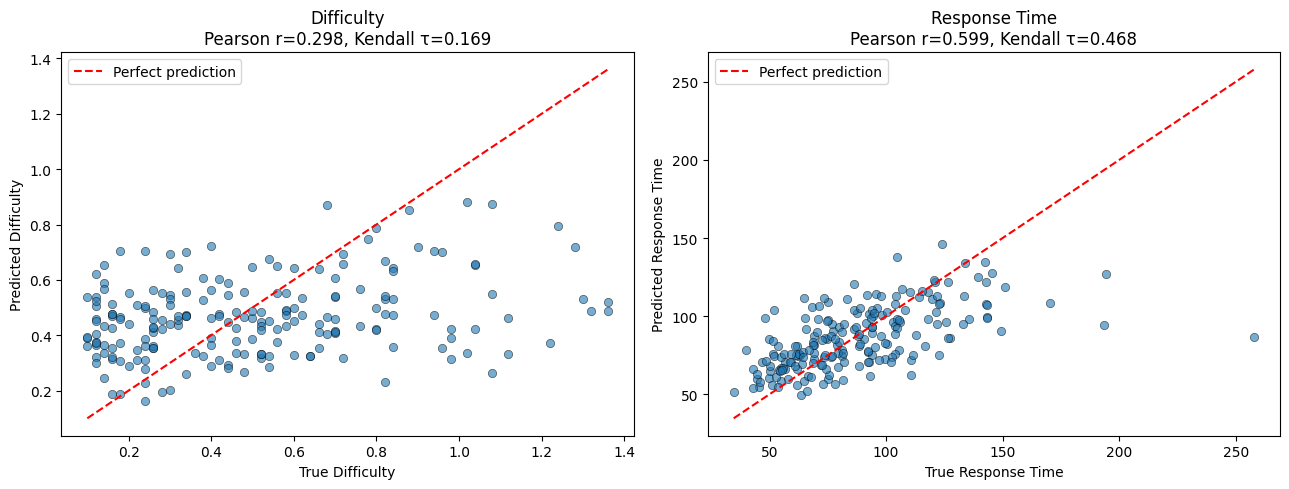


Results saved to: /Results/diff_r0.298_tau0.169__rtime_r0.599_tau0.468


In [28]:
# Project root → same resolution as data_path above
_project_root = os.path.dirname(os.path.dirname(os.getcwd()))

if not has_test_labels:
    print("No ground-truth labels available for the test set — skipping metrics.")
    _folder_name = f"no_labels_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
    _results_dir = os.path.join(_project_root, "Results", _folder_name)
    os.makedirs(_results_dir, exist_ok=True)
    df_out.to_csv(os.path.join(_results_dir, "predictions.csv"), index=False)
    torch.save(model.state_dict(), os.path.join(_results_dir, "model.pt"))
    _nb_src = os.path.join(os.getcwd(), "ModernBert_LoRA_Dualgate.ipynb")
    if os.path.exists(_nb_src):
        shutil.copy2(_nb_src, os.path.join(_results_dir, "ModernBert_LoRA_Dualgate.ipynb"))
    print(f"Results saved to: {_results_dir}")
else:
    true_diff  = scaler_difficulty.inverse_transform(
        labels_test_diff.numpy().reshape(-1, 1)).flatten()
    true_rtime = scaler_time.inverse_transform(
        labels_test_rtime.numpy().reshape(-1, 1)).flatten()

    def _metrics(true, pred, name):
        mse          = mean_squared_error(true, pred)
        r,   rp      = pearsonr(true, pred)
        tau, taup    = kendalltau(true, pred)
        print(f"\n  [{name}]")
        print(f"    RMSE      : {np.sqrt(mse):.4f}")
        print(f"    Pearson r : {r:.4f}  (p={rp:.2e})")
        print(f"    Kendall τ : {tau:.4f}  (p={taup:.2e})")
        return r, tau

    print("=== Test Set Evaluation ===")
    r_d,   tau_d   = _metrics(true_diff,  preds_diff,  "Difficulty")
    r_r,   tau_r   = _metrics(true_rtime, preds_rtime, "Response Time")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, true, pred, name, r, tau in [
        (axes[0], true_diff,  preds_diff,  "Difficulty",    r_d,   tau_d),
        (axes[1], true_rtime, preds_rtime, "Response Time", r_r,   tau_r),
    ]:
        ax.scatter(true, pred, alpha=0.6, edgecolors="k", linewidths=0.5)
        lims = [min(true.min(), pred.min()), max(true.max(), pred.max())]
        ax.plot(lims, lims, "r--", label="Perfect prediction")
        ax.set_xlabel(f"True {name}")
        ax.set_ylabel(f"Predicted {name}")
        ax.set_title(f"{name}\nPearson r={r:.3f}, Kendall τ={tau:.3f}")
        ax.legend()

    plt.tight_layout()

    # ── Save results ──────────────────────────────────────────────────────────
    _folder_name = (
        f"diff_r{r_d:.3f}_tau{tau_d:.3f}"
        f"__rtime_r{r_r:.3f}_tau{tau_r:.3f}"
    )
    _results_dir = os.path.join(_project_root, "Results", _folder_name)
    os.makedirs(_results_dir, exist_ok=True)

    # 1. Predictions CSV
    df_out.to_csv(os.path.join(_results_dir, "predictions.csv"), index=False)

    # 2. Model weights
    torch.save(model.state_dict(), os.path.join(_results_dir, "model.pt"))

    # 3. Metrics summary
    with open(os.path.join(_results_dir, "metrics.txt"), "w") as _f:
        _f.write("=== Test Set Evaluation ===\n\n")
        _f.write("[Difficulty]\n")
        _f.write(f"  RMSE      : {np.sqrt(mean_squared_error(true_diff, preds_diff)):.4f}\n")
        _f.write(f"  Pearson r : {r_d:.4f}\n")
        _f.write(f"  Kendall t : {tau_d:.4f}\n\n")
        _f.write("[Response Time]\n")
        _f.write(f"  RMSE      : {np.sqrt(mean_squared_error(true_rtime, preds_rtime)):.4f}\n")
        _f.write(f"  Pearson r : {r_r:.4f}\n")
        _f.write(f"  Kendall t : {tau_r:.4f}\n")

    # 4. Scatter plot
    fig.savefig(os.path.join(_results_dir, "scatter_plot.png"), dpi=150, bbox_inches="tight")

    # 5. Notebook copy
    _nb_src = os.path.join(os.getcwd(), "ModernBert_LoRA_Dualgate.ipynb")
    if os.path.exists(_nb_src):
        shutil.copy2(_nb_src, os.path.join(_results_dir, "ModernBert_LoRA_Dualgate.ipynb"))

    plt.show()
    print(f"\nResults saved to: {_results_dir}")


In [29]:
# Ensemble Method
# Standard single-stream model that trains two separate instances.

class S_S_Model(torch.nn.Module):
    def __init__(self, encoder: torch.nn.Module, hidden_size: int, include_confidence_score: bool = False):
        super().__init__()
        # The base transformer model goes here
        self.encoder = encoder
        self.include_confidence_score = include_confidence_score # Remember if its fed to the extra LLM numbers or not

        in_features = hidden_size + (4 if include_confidence_score else 0)  # (Base features + 4 extra numbers if flag is true)


        self.head_difficulty = torch.nn.Linear(in_features, 1)
        self.head_response_time = torch.nn.Linear(in_features, 1)

    # helper to average out word tokens into a single sentence vector
    def _encode(self, input_ids, attention_mask):
        # Run text through the transformer and takes all the token embeddings
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        hidden = out.last_hidden_state

        mask = attention_mask.unsqueeze(-1).float() # Used to ignore the padding tokens like the 0's.

        summed = (hidden * mask).sum(dim = 1)

        # Count the actual tokens and returns the average.
        counts = mask.sum(dim = 1).clamp(min = 1e-9)
        return summed / counts

    def forward(self, input_ids, attention_mask, conf=None):
        # Get the pooled sentence vector using _encode.
        pool = self._encode(input_ids, attention_mask)

        # If we have the extra LLM confidence numbers, add them to the end of the text features
        if self.include_confidence_score and conf is not None:
            pool = torch.cat([pool, conf], dim = -1)

        pred_diff = torch.sigmoid(self.head_difficulty(pool)).squeeze(-1)
        pred_rtime = torch.sigmoid(self.head_response_time(pool)).squeeze(-1)

        return pred_diff, pred_rtime

# Build a model to prevent clutter.
def build_single_model(include_confidence_score=False) -> S_S_Model:
    base = AutoModel.from_pretrained(MODEL_NAME) # the large pre-trained model

    # LoRA config. Lora_dropout is 10% to prevent it from memorizing the training data.
    lora_cfg = LoraConfig(
        task_type=TaskType.FEATURE_EXTRACTION,
        r=32,
        lora_alpha=32,
        target_modules="all-linear",
        lora_dropout=0.1,
        bias="none",
    )

    encoder = get_peft_model(base, lora_cfg)

    # custom class with the LoRA encoder inside it
    return S_S_Model(encoder, base.config.hidden_size, include_confidence_score)

In [30]:
print("Initializing Ensemble Models...")
model_question = build_single_model(include_confidence_score=False).to(device) # The first model that only looks at the text
model_llm = build_single_model(include_confidence_score=True).to(device) # the second model that looks at text and the LLM confidence scores

# AdamW optimizers
opt_question = torch.optim.AdamW(model_question.parameters(), lr=LR, eps = 1e-8)
opt_llm = torch.optim.AdamW(model_llm.parameters(), lr = LR, eps = 1e-8)

# Slowly lower the learning rate over time to prevent overcorrection at the end.
sched_question = get_linear_schedule_with_warmup(opt_question, num_warmup_steps=0, num_training_steps=len(train_dl) * EPOCHS)
sched_llm = get_linear_schedule_with_warmup(opt_llm, num_warmup_steps=0, num_training_steps=len(train_dl) * EPOCHS)

criterion = torch.nn.HuberLoss(delta=0.1) # Huber loss because the response times because of outliers.
amp_scaler = torch.amp.GradScaler("cuda") if use_amp else None # Mixed precision scaler. Could make the training much faster.


print("\nTraining Ensemble (Model Question & Model LLM)...")
for epoch in range(1, EPOCHS + 1):
    model_question.train()
    model_llm.train()

    loss_question_total = 0.0
    loss_llm_total = 0.0

    # Going through the data loader by each batch
    for ids_q, mask_q, ids_llm, mask_llm, conf, lbl_diff, lbl_rtime in train_dl:
        ids_q, mask_q = ids_q.to(device), mask_q.to(device)
        ids_llm, mask_llm = ids_llm.to(device), mask_llm.to(device)
        conf, lbl_diff, lbl_rtime = conf.to(device), lbl_diff.to(device), lbl_rtime.to(device)


        # ------Train Question-Only Model------
        model_question.zero_grad() # Reset the gradients from the previous loop

        # If use_amp is true, this does the math in 16-bit to go faster
        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            # Get predictions
            pred_diff_q, pred_rtime_q = model_question(ids_q, mask_q)
            # add the 2 losses together and multiple by 0.5 to prevent the difficulty learning from being overpowered.
            loss_q = criterion(pred_diff_q, lbl_diff) + criterion(pred_rtime_q, lbl_rtime) * 0.5

        if amp_scaler:
            amp_scaler.scale(loss_q).backward()
            torch.nn.utils.clip_grad_norm_(model_question.parameters(), 1.0)
            amp_scaler.step(opt_question)
            amp_scaler.update()
        else:
            # Normal backprop if I'm not using the speedup scaler
            loss_q.backward()
            torch.nn.utils.clip_grad_norm_(model_question.parameters(), 1.0)
            opt_question.step()

        sched_question.step()
        loss_question_total += loss_q.item() # Add to running total


        # -----Train LLM-Augmented Model-----
        model_llm.zero_grad()
        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            pred_diff_llm, pred_rtime_llm = model_llm(ids_llm, mask_llm, conf)
            loss_llm = criterion(pred_diff_llm, lbl_diff) + criterion(pred_rtime_llm, lbl_rtime) * 0.5

        if amp_scaler:
            amp_scaler.scale(loss_llm).backward()
            torch.nn.utils.clip_grad_norm_(model_llm.parameters(), 1.0)
            amp_scaler.step(opt_llm)
            amp_scaler.update()
        else:
            loss_llm.backward()
            torch.nn.utils.clip_grad_norm_(model_llm.parameters(), 1.0)
            opt_llm.step()

        sched_llm.step()
        loss_llm_total += loss_llm.item()

    print(f"Epoch {epoch}/{EPOCHS} | Model Question Loss: {loss_question_total/len(train_dl):.4f} | Model LLM Loss: {loss_llm_total/len(train_dl):.4f}")

Initializing Ensemble Models...


Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Training Ensemble (Model Question & Model LLM)...
Epoch 1/10 | Model Question Loss: 0.0230 | Model LLM Loss: 0.0209
Epoch 2/10 | Model Question Loss: 0.0174 | Model LLM Loss: 0.0177
Epoch 3/10 | Model Question Loss: 0.0170 | Model LLM Loss: 0.0174
Epoch 4/10 | Model Question Loss: 0.0166 | Model LLM Loss: 0.0170
Epoch 5/10 | Model Question Loss: 0.0163 | Model LLM Loss: 0.0167
Epoch 6/10 | Model Question Loss: 0.0163 | Model LLM Loss: 0.0168
Epoch 7/10 | Model Question Loss: 0.0160 | Model LLM Loss: 0.0164
Epoch 8/10 | Model Question Loss: 0.0160 | Model LLM Loss: 0.0164
Epoch 9/10 | Model Question Loss: 0.0161 | Model LLM Loss: 0.0164
Epoch 10/10 | Model Question Loss: 0.0157 | Model LLM Loss: 0.0160


In [31]:
# Eval used to prevent updating weights or dropout while testing
model_question.eval()
model_llm.eval()

# ----- Ensemble Hyperparameter Tuning -----
# alpha is the weight for the stronger model_llm.
# The remaining fraction (1 - alpha) will be used to the weaker model_question.
alpha = 0.85

# Holds all the final answers
ensemble_prediction_difficulty = []
ensemble_prediction_runtime = []

print(f"Running Inference with Weighted Ensemble (alpha = {alpha})...")
# no_grad() used to save memory by stopping PyTorch from tracking the math for backprop
with torch.no_grad():
    for ids_q, mask_q, ids_llm, mask_llm, conf, item_nums, *_ in test_dl:
        ids_q, mask_q = ids_q.to(device), mask_q.to(device)
        ids_llm, mask_llm = ids_llm.to(device), mask_llm.to(device)
        conf = conf.to(device)

        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            diff_q, rtime_q = model_question(ids_q, mask_q)
            diff_llm, rtime_llm = model_llm(ids_llm, mask_llm, conf)

        # Weighted Average of the predictions (Important part of Weighted Ensemble)
        weighted_difficulty = (alpha * diff_llm) + ((1.0 - alpha) * diff_q)
        weighted_runtime = (alpha * rtime_llm) + ((1.0 - alpha) * rtime_q)

        ensemble_prediction_difficulty.extend(weighted_difficulty.cpu().numpy())
        ensemble_prediction_runtime.extend(weighted_runtime.cpu().numpy())

# Inverse Transform back to baseline scale
ensemble_prediction_difficulty = scaler_difficulty.inverse_transform(np.array(ensemble_prediction_difficulty).reshape(-1, 1)).flatten()
ensemble_prediction_runtime = scaler_time.inverse_transform(np.array(ensemble_prediction_runtime).reshape(-1, 1)).flatten()

# Output the Metrics
if has_test_labels:
    print("\nEnsemble Test Set Evaluation:")
    r_d_ens, tau_d_ens = _metrics(true_diff, ensemble_prediction_difficulty, "Ensemble Difficulty")
    r_r_ens, tau_r_ens = _metrics(true_rtime, ensemble_prediction_runtime, "Ensemble Response Time")

Running Inference with Weighted Ensemble (alpha = 0.85)...

Ensemble Test Set Evaluation:

  [Ensemble Difficulty]
    RMSE      : 0.3131
    Pearson r : 0.1962  (p=5.26e-03)
    Kendall τ : 0.1227  (p=1.06e-02)

  [Ensemble Response Time]
    RMSE      : 30.0949
    Pearson r : 0.4587  (p=7.44e-12)
    Kendall τ : 0.3492  (p=2.02e-13)
